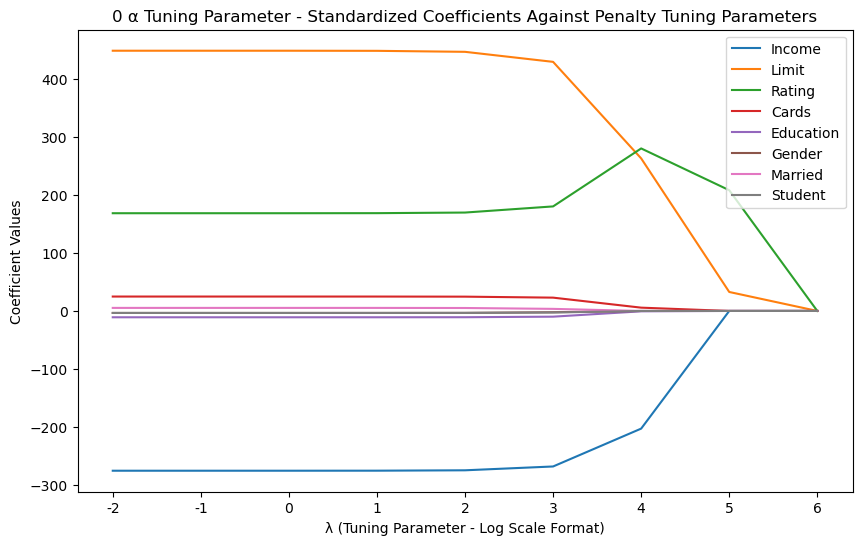

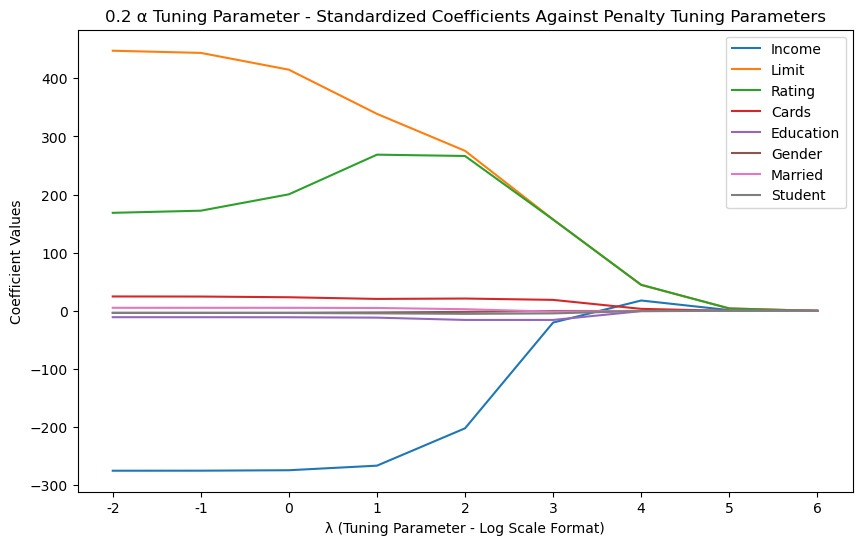

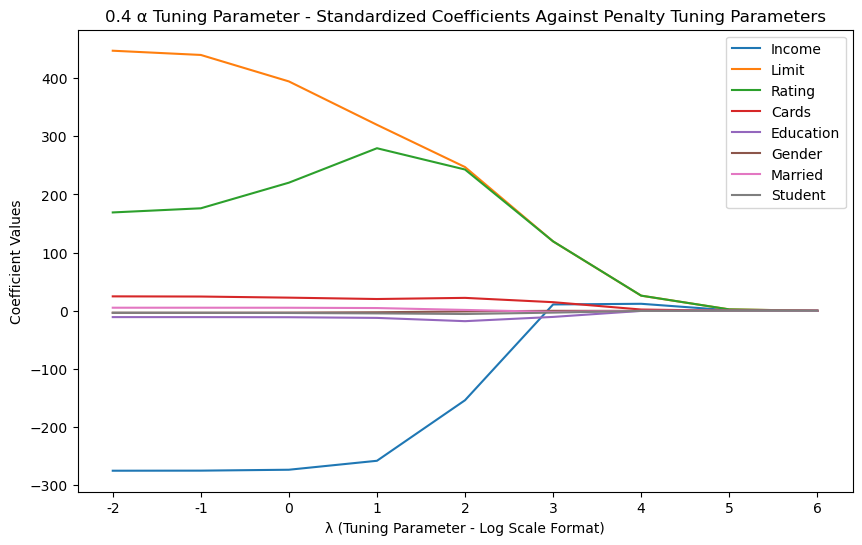

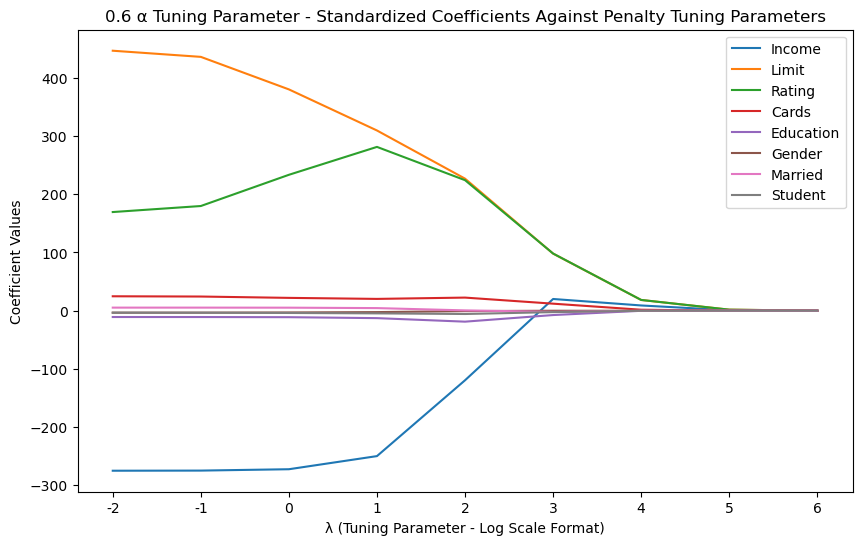

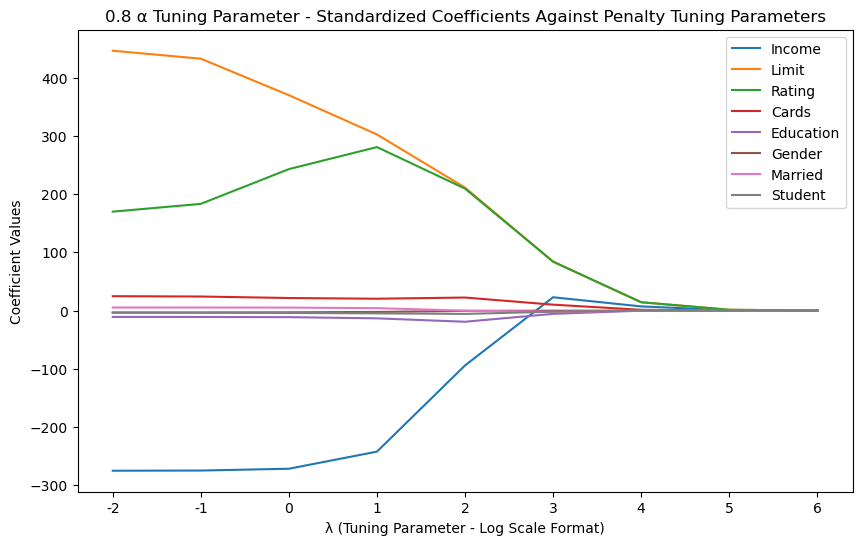

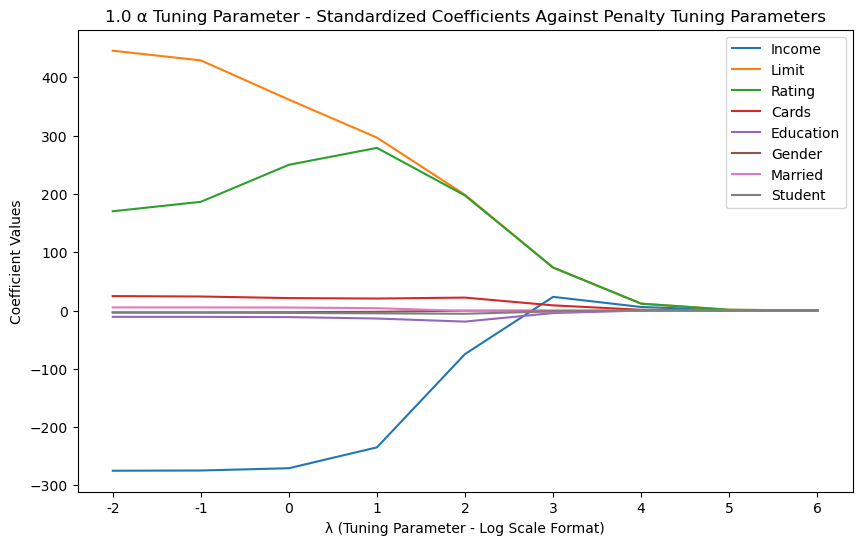

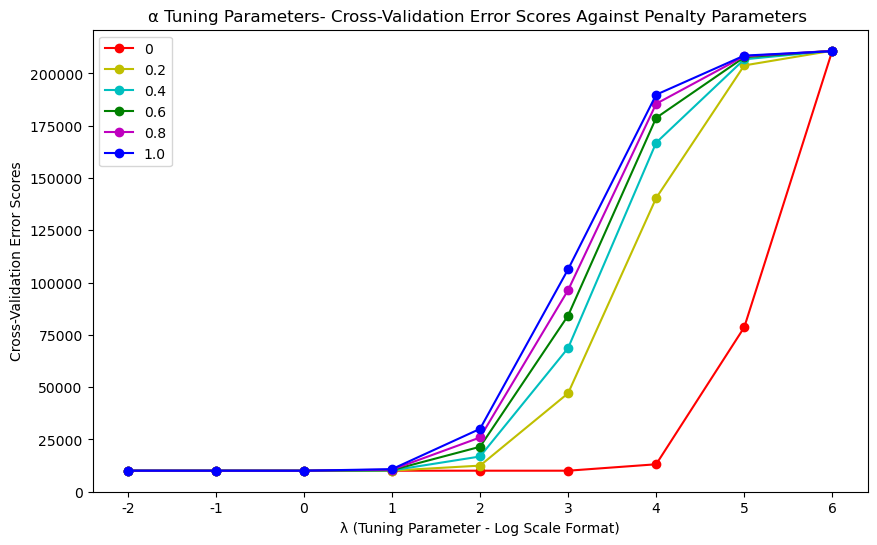

The lowest cross-validation error score achieved: 10032.936121405175
Alpha tuning parameter used: 0.4
The lambda parameter that resulted in the lowest cross-validation score: 1
[[10049.461370737616, 10049.469962856248, 10049.418478125071, 10048.965677250211, 10044.884977044887, 10042.088399740514, 13114.172936039166, 78612.00963252691, 210849.77977500003], [10049.238212811699, 10047.256126683806, 10035.988058841574, 10074.743285306638, 12470.406933302811, 47070.061624026755, 140421.878798383, 203815.20137203851, 210849.77977500003], [10048.999945391788, 10045.291420489379, 10032.936121405175, 10183.333063083352, 16837.419504567944, 68688.60994841057, 166888.95310383124, 206729.0114379277, 210849.77977500003], [10048.79294513645, 10043.56148720016, 10034.003057353846, 10342.30249333267, 21478.65829245367, 84200.08991320299, 178756.3738179977, 207712.19132973746, 210849.77977500003], [10048.551070608077, 10042.027679271805, 10037.135591529635, 10546.205372541357, 25922.02847347883, 96372

In [3]:
#Starting libraries
#The necessary libraries are included here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image





# Load and preprocess data
filename = "Credit_N400_p9.csv"
advertising_df = pd.read_csv(filename)

# Separate target and features
x_features_df = advertising_df.copy(deep=True)
y_features_df = x_features_df.pop("Balance")

# Convert categorical variables to dummy variables
x_features_df = pd.get_dummies(x_features_df, columns = ["Gender"], drop_first=True, dtype=int)
x_features_df = pd.get_dummies(x_features_df, columns = ["Married"], drop_first=True, dtype=int)
x_features_df = pd.get_dummies(x_features_df, columns = ["Student"], drop_first=True, dtype=int)

# Standardize features and target
X_standardized = (x_features_df - x_features_df.mean()) / x_features_df.std()
y_standardized = y_features_df - y_features_df.mean()

# Convert to numpy arrays for efficiency
X = X_standardized.to_numpy()
y = y_standardized.to_numpy()

# Define algorithm parameters
alpha_tuning_parameter_set = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
lambda_tuning_parameter_set = [10**-2, 10**-1, 10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
k_folds = 5
k_N_Splits = len(y) // k_folds
coordinate_descent_loop = 1000

observations_N = len(X_standardized)

# Initialize holders for cross-validation results
cross_validation_account_final = []
vector_parameter_beta_final = []
cross_validation_beta_account_final = []


def cross_validate_elastic_net(alpha_etp_set, lambda_etp_set, k_N_Splits, k_folds, cd_loop, X, y):
    

    
    

    for current_alpha_etp in range(len(alpha_etp_set)):
        chosen_alpha_etp = alpha_etp_set[current_alpha_etp]
        alpha_etp_cvse_account = []
        alpha_etp_vector_beta_account = []

        for current_lambda_etp in range(len(lambda_etp_set)):
            chosen_lambda_etp = lambda_etp_set[current_lambda_etp]
            lambda_etp_csve_account = []
            lambda_etp_vector_beta_account = []
            
            #random_reorder = np.random.permutation(observations_N)

            for fold in range(k_folds):
                
                beg_index = fold * k_N_Splits
                end_index = (fold + 1) * k_N_Splits
                beg_to_end_indexes = np.arange(beg_index, end_index)
                
                X_validation_set = X[beg_to_end_indexes]
                y_validation_set = y[beg_to_end_indexes]
                
                # Split data for validation and training
                # start, end = fold * k_N_Splits, (fold + 1) * k_N_Splits
                # X_validation_set, y_validation_set = X[start:end], y[start:end]
                X_training_set = np.delete(X, beg_to_end_indexes, axis=0)
                y_training_set = np.delete(y, beg_to_end_indexes, axis=0)

                # Precompute b_k for training set
                

                
                # Initialize beta for coordinate descent
                intermediate_beta = np.random.uniform(-1, 1, X_training_set.shape[1])
                
                # Perform coordinate descent for the elastic net
                for current_iteration in range(cd_loop):
                    for k in range(len(intermediate_beta)):
                        # Calculate r_k using the current intermediate_beta
                        b_k_en = np.sum(X_training_set ** 2, axis=0)
                        
                        
                        
                        a_k_p1 = X_training_set[:, k] * intermediate_beta[k]
                        a_k_p2 = y_training_set - X_training_set.dot(intermediate_beta) + a_k_p1
                        
                        a_k_en = X_training_set[:, k].dot(a_k_p2)

                        beta_algo_p1 = chosen_lambda_etp * (1 - chosen_alpha_etp) / 2
                        beta_algo_p2 = b_k_en[k] + chosen_lambda_etp * chosen_alpha_etp
                        
                        
                        # Update intermediate_beta[k] using the elastic net formula
                        if a_k_en > chosen_lambda_etp * (1 - chosen_alpha_etp) / 2:
                            intermediate_beta[k] = (a_k_en - beta_algo_p1) / beta_algo_p2
                        elif a_k_en < -chosen_lambda_etp * (1 - chosen_alpha_etp) / 2:
                            intermediate_beta[k] = (a_k_en + beta_algo_p1) / beta_algo_p2
                        else:
                            intermediate_beta[k] = 0

                # Validation error
                y_prediction_set = X_validation_set.dot(intermediate_beta)

                validation_error_score = np.sum((y_validation_set - y_prediction_set)**2) / len(y_validation_set)
                lambda_etp_csve_account.append(validation_error_score)
                lambda_etp_vector_beta_account.append(intermediate_beta.copy())

            # Append fold results for current alpha-lambda pair
            alpha_etp_cvse_account.append(np.mean(lambda_etp_csve_account))
            alpha_etp_vector_beta_account.append(np.mean(lambda_etp_vector_beta_account, axis=0))
        
        # Store results for current alpha in global arrays
        cross_validation_account_final.append(alpha_etp_cvse_account)
        vector_parameter_beta_final.append(alpha_etp_vector_beta_account)
    
    return cross_validation_account_final, vector_parameter_beta_final

# Run cross-validation
cross_validation_account_final, vector_parameter_beta_final = cross_validate_elastic_net(alpha_tuning_parameter_set, lambda_tuning_parameter_set, k_N_Splits, k_folds, coordinate_descent_loop, X, y)


    
    

# Define new plotting function
def coeffecientsvptp(current_vector_param_b, lambda_tuning_parameter_set, graph_title):
    # Ensure coefficients are in numpy format for easy indexing
    current_vector_param_b = np.array(current_vector_param_b)
    
    # Log scale labels for the lambda values
    tp_log_set = [-2, -1, 0, 1, 2, 3, 4, 5, 6]

    plt.figure(figsize=(10, 6))
    # Plot each feature's coefficient path against lambda on a log scale
    plt.semilogx(lambda_tuning_parameter_set, current_vector_param_b[:,0], label="Income")
    plt.semilogx(lambda_tuning_parameter_set, current_vector_param_b[:,1], label="Limit")
    plt.semilogx(lambda_tuning_parameter_set, current_vector_param_b[:,2], label="Rating")
    plt.semilogx(lambda_tuning_parameter_set, current_vector_param_b[:,3], label="Cards")
    plt.semilogx(lambda_tuning_parameter_set, current_vector_param_b[:,4], label="Education")
    plt.semilogx(lambda_tuning_parameter_set, current_vector_param_b[:,5], label="Gender")
    plt.semilogx(lambda_tuning_parameter_set, current_vector_param_b[:,6], label="Married")
    plt.semilogx(lambda_tuning_parameter_set, current_vector_param_b[:,7], label="Student")

    # Set labels and titles
    plt.xticks(ticks=lambda_tuning_parameter_set, labels=tp_log_set)
    plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
    plt.ylabel('Coefficient Values')
    plt.title(graph_title)
    plt.legend(loc=1)
    plt.show()

# Loop through each alpha to plot coefficient paths for each
for current_alpha_etp in range(len(alpha_tuning_parameter_set)):
    # Get the coefficient paths for the current alpha value
    current_vector_param_b = np.array(vector_parameter_beta_final[current_alpha_etp])
    
    # Title for each plot
    graph_title = str(alpha_tuning_parameter_set[current_alpha_etp]) + " α Tuning Parameter - Standardized Coefficients Against Penalty Tuning Parameters"
    
    # Call the plotting function
    coeffecientsvptp(current_vector_param_b, lambda_tuning_parameter_set, graph_title)

def errorvpenaltyperetp(cv_account_current, graph_title):
    tp_log_set = [-2,-1,0,1,2,3,4,5,6]
    #This graph shows the cross validation error scores across all of the penalty terms
    plt.figure(figsize=(10, 6))
    plt.semilogx(lambda_tuning_parameter_set, cv_account_current[0], 'ro-', label= alpha_tuning_parameter_set[0])
    plt.semilogx(lambda_tuning_parameter_set, cv_account_current[1], 'yo-', label= alpha_tuning_parameter_set[1])
    plt.semilogx(lambda_tuning_parameter_set, cv_account_current[2], 'co-', label= alpha_tuning_parameter_set[2])
    plt.semilogx(lambda_tuning_parameter_set, cv_account_current[3], 'go-', label= alpha_tuning_parameter_set[3])
    plt.semilogx(lambda_tuning_parameter_set, cv_account_current[4], 'mo-', label= alpha_tuning_parameter_set[4])
    plt.semilogx(lambda_tuning_parameter_set, cv_account_current[5], 'bo-', label= alpha_tuning_parameter_set[5])
    plt.xticks(ticks=lambda_tuning_parameter_set, labels=tp_log_set)
    plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
    plt.ylabel('Cross-Validation Error Scores')
    #plt.title('Cross-Validation Error Scores Against Penalty Parameters')
    plt.title(graph_title)
    plt.legend(loc=2)
    plt.show()

graph_title = "α Tuning Parameters- Cross-Validation Error Scores Against Penalty Parameters "
errorvpenaltyperetp(cross_validation_account_final,  graph_title)

# Initialize to find the lowest cross-validation error and corresponding alpha and lambda
lowest_cross_validation_errors = []
placeholder_cve = min(cross_validation_account_final[0])
placeholder_etp_position = 0  # Fixing the typo here

for current_alpha_etp in range(len(alpha_tuning_parameter_set)):
    lowest_cross_validation_error = min(cross_validation_account_final[current_alpha_etp])
    if lowest_cross_validation_error < placeholder_cve:
        placeholder_cve = lowest_cross_validation_error
        placeholder_etp_position = current_alpha_etp  # Fixing the typo here

print("The lowest cross-validation error score achieved: " + str(placeholder_cve))
print("Alpha tuning parameter used: " + str(alpha_tuning_parameter_set[placeholder_etp_position]))  # Using alpha_tuning_parameter_set instead of elastic_tuning_parameter_set

# Find the lambda parameter that resulted in the lowest cross-validation score
tuning_parameter_lowest_cv = 0
cva_final = cross_validation_account_final[placeholder_etp_position]  # Use the correct position

for i in range(len(cva_final)):
    if cva_final[i] == placeholder_cve:
        tuning_parameter_lowest_cv = lambda_tuning_parameter_set[i]

print("The lambda parameter that resulted in the lowest cross-validation score: " + str(tuning_parameter_lowest_cv))

print(cross_validation_account_final)

final_alpha_tp = alpha_tuning_parameter_set[placeholder_etp_position]
final_lambda_tp = tuning_parameter_lowest_cv


def non_cross_validation_elastic_net(chosen_alpha_tp, chosen_lambda_tp, coordinate_descent_loop, X, y):
    # Precompute b_k for training set
    

    # Initialize beta for coordinate descent
    intermediate_beta = np.random.uniform(-1, 1, X.shape[1])
    
    
    
    # Perform coordinate descent for the elastic net
    for current_cd_iteration in range(coordinate_descent_loop):
        for beta_current in range(len(intermediate_beta)):
            
            
            b_k = np.sum(X ** 2, axis=0)
            # Calculate r_k using the current beta
            a_k_p1 = X[:, beta_current] * intermediate_beta[beta_current]
            a_k_p2 = y - X.dot(intermediate_beta) + a_k_p1
            a_k_final = X[:, beta_current].dot(a_k_p2)
            
            intermediate_beta_p1 = chosen_lambda_tp * (1 - chosen_alpha_tp) / 2
            intermediate_beta_p2 = b_k[beta_current] + chosen_lambda_tp * chosen_alpha_tp
            # Update beta[beta_current] using the elastic net formula
            if a_k_final > chosen_lambda_tp * (1 - chosen_alpha_tp) / 2:
                
                
                intermediate_beta[beta_current] = (a_k_final - intermediate_beta_p1) / intermediate_beta_p2
            elif a_k_final < -chosen_lambda_tp * (1 - chosen_alpha_tp) / 2:
                
                
                intermediate_beta[beta_current] = (a_k_final + intermediate_beta_p1) / (intermediate_beta_p2)
            else:
                
                
                intermediate_beta[beta_current] = 0

    return intermediate_beta

final_vector_param_beta = non_cross_validation_elastic_net(final_alpha_tp, final_lambda_tp, coordinate_descent_loop, X, y)
y_final_predicted = X.dot(final_vector_param_beta)
mean_squared_error = np.sum((y - y_final_predicted) ** 2) / len(y)

#This prints out the beta parameters based on the model that used all the observation data
#The values are rounded to the fourth decimal point
print("9 Best Fit Model Parameters Based On Tuning Parameters That Produced The Lowest Cross-Validation Error Score: ")
#Income	Limit	Rating	Cards	Age	Education	Gender_Male	Married_Yes	Student_Yes


print("Income: " + str(round(final_vector_param_beta[0], 4)))
print("Limit: " + str(round(final_vector_param_beta[1], 4)))
print("Rating: " + str(round(final_vector_param_beta[2], 4)))
print("Cards: " + str(round(final_vector_param_beta[3], 4)))
print("Age: " + str(round(final_vector_param_beta[4], 4)))
print("Education: " + str(round(final_vector_param_beta[5], 4)))
print("Gender: " + str(round(final_vector_param_beta[6], 4)))
print("Married: " + str(round(final_vector_param_beta[7], 4)))
print("Student: " + str(round(final_vector_param_beta[8], 4)))

ridge_final_vector_param_beta = non_cross_validation_elastic_net(1, final_lambda_tp, coordinate_descent_loop, X, y)
y_final_predicted = X.dot(ridge_final_vector_param_beta)
mean_squared_error = np.sum((y - y_final_predicted) ** 2) / len(y)

#This prints out the beta parameters based on the model that used all the observation data
#The values are rounded to the fourth decimal point
print("9 Best Fit Model Parameters Based On One Optimal Parameter And An Alpha Tuning Parameter Of 1: ")
print("(Ridge Regression) ")
#Income	Limit	Rating	Cards	Age	Education	Gender_Male	Married_Yes	Student_Yes


print("Income: " + str(round(ridge_final_vector_param_beta[0], 4)))
print("Limit: " + str(round(ridge_final_vector_param_beta[1], 4)))
print("Rating: " + str(round(ridge_final_vector_param_beta[2], 4)))
print("Cards: " + str(round(ridge_final_vector_param_beta[3], 4)))
print("Age: " + str(round(ridge_final_vector_param_beta[4], 4)))
print("Education: " + str(round(ridge_final_vector_param_beta[5], 4)))
print("Gender: " + str(round(ridge_final_vector_param_beta[6], 4)))
print("Married: " + str(round(ridge_final_vector_param_beta[7], 4)))
print("Student: " + str(round(ridge_final_vector_param_beta[8], 4)))

lasso_final_vector_param_beta = non_cross_validation_elastic_net(0, final_lambda_tp, coordinate_descent_loop, X, y)
y_final_predicted = X.dot(ridge_final_vector_param_beta)
mean_squared_error = np.sum((y - y_final_predicted) ** 2) / len(y)

#This prints out the beta parameters based on the model that used all the observation data
#The values are rounded to the fourth decimal point
print("9 Best Fit Model Parameters Based On One Optimal Parameter And An Alpha Tuning Parameter Of 0: ")
print("(Lasso Regression) ")
#Income	Limit	Rating	Cards	Age	Education	Gender_Male	Married_Yes	Student_Yes


print("Income: " + str(round(lasso_final_vector_param_beta[0], 4)))
print("Limit: " + str(round(lasso_final_vector_param_beta[1], 4)))
print("Rating: " + str(round(lasso_final_vector_param_beta[2], 4)))
print("Cards: " + str(round(lasso_final_vector_param_beta[3], 4)))
print("Age: " + str(round(lasso_final_vector_param_beta[4], 4)))
print("Education: " + str(round(lasso_final_vector_param_beta[5], 4)))
print("Gender: " + str(round(lasso_final_vector_param_beta[6], 4)))
print("Married: " + str(round(lasso_final_vector_param_beta[7], 4)))
print("Student: " + str(round(lasso_final_vector_param_beta[8], 4)))